<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.

Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

In [242]:
!pip install gdown

!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [244]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

In [245]:
data.columns

Index(['name', 'title', 'male', 'culture', 'dateOfBirth', 'mother', 'father',
       'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive'],
      dtype='object')

### Предобработка и очистка данных

Посмотрим на то, какие вообще у нас есть признаки и какие из них, качественные, а какие числовые

In [246]:
data.columns

Index(['name', 'title', 'male', 'culture', 'dateOfBirth', 'mother', 'father',
       'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive'],
      dtype='object')

In [247]:
data.describe(include = 'object').T.assign(NaN_percent = ((data.isna().sum() / len(data)) * 100).round(2) )

,count,unique,top,freq,NaN_percent
name,1557,1557,Viserys II Targaryen,1,0.00
title,717,195,Ser,306,53.95
culture,488,51,Northmen,94,68.66
mother,18,16,Rhaenyra Targaryen,2,98.84
father,22,19,Daemon Targaryen,2,98.59
heir,21,20,Jaehaerys Targaryen,2,98.65
house,1176,315,House Frey,89,24.47
spouse,200,186,Walder Frey,6,87.15


In [248]:
data.describe(include = 'number').T[['count', 'min', 'max']].assign(NaN_percent = ((data.isna().sum() / len(data)) * 100).round(2) )

,count,min,max,NaN_percent
male,1557.0,0.0,1.0,0.00
dateOfBirth,279.0,-25.0,299.0,82.08
book1,1557.0,0.0,1.0,0.00
book2,1557.0,0.0,1.0,0.00
book3,1557.0,0.0,1.0,0.00
book4,1557.0,0.0,1.0,0.00
book5,1557.0,0.0,1.0,0.00
isAliveMother,18.0,0.0,1.0,98.84
isAliveFather,22.0,0.0,1.0,98.59
isAliveHeir,21.0,0.0,1.0,98.65


Как видно есть колонки, в которых подавляющее большинство данных NaN. Например, `isAliveMother`, `isAliveFather`, `isAliveHeir` (чуть больше мы знаем про `isAliveSpouse`, но больше 87% все равно NaN). Много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.

Мы пока не можем переходить к анализу, даже предварительному, бесполезно скейлить и смотреть на корреляцию числовых признаков, данные слишком грязные. Исправим это. Начнем с числовых признаков (включая бинарные) - избавимся от NaN и объединим некоторые признаки. 

#### Числовые признаки

Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. 

In [249]:
# пока тут, потом избавимся от части и часть преобразуем
numeric_features = data.select_dtypes(include='number').columns.tolist()
numeric_features

['male',
 'dateOfBirth',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse',
 'isMarried',
 'isNoble',
 'age',
 'numDeadRelations',
 'popularity',
 'isAlive']

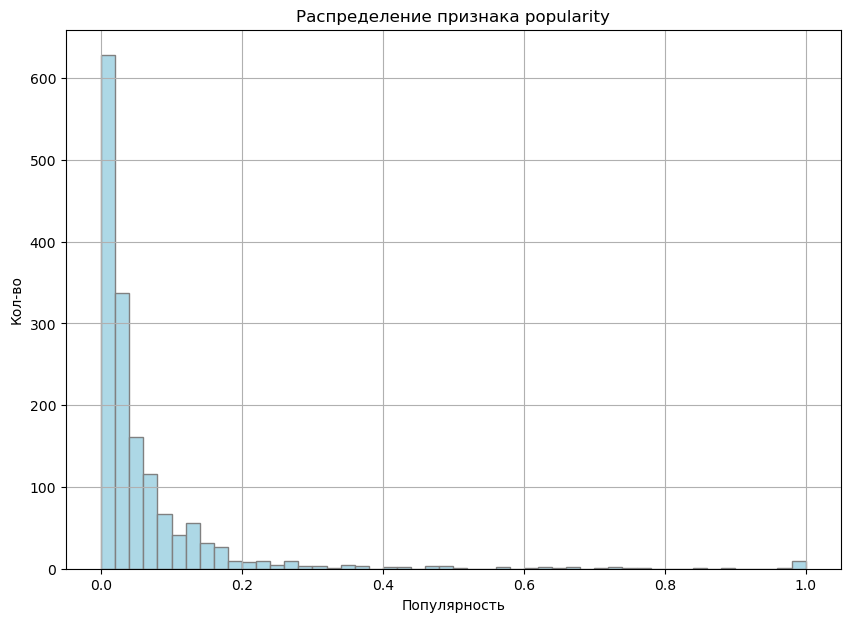

In [250]:
plt.figure(figsize=(10, 7))
plt.hist(data['popularity'], bins=50, color='lightblue', edgecolor='grey')
plt.title('Распределение признака popularity')
plt.xlabel('Популярность')
plt.ylabel('Кол-во')
plt.grid(True)
plt.show()

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для нектоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.

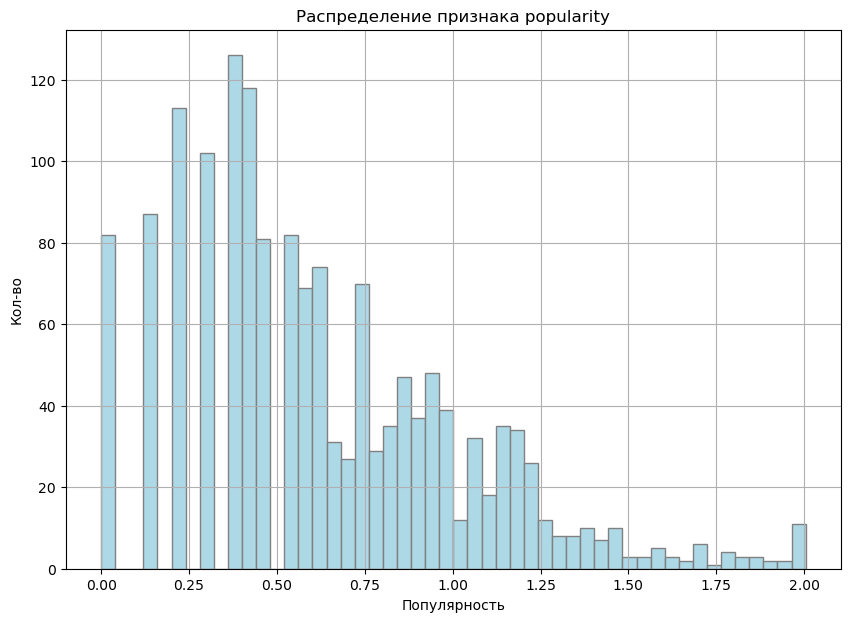

In [251]:
M = 100
data['popularity_log'] = np.log10(data['popularity'] * M + 1)
plt.figure(figsize=(10, 7))
plt.hist(data['popularity_log'], bins=50, color='lightblue', edgecolor='grey')
plt.title('Распределение признака popularity')
plt.xlabel('Популярность')
plt.ylabel('Кол-во')
plt.grid(True)
plt.show()

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрим на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [252]:
data['numDeadRelations'].value_counts().sort_index()

0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: numDeadRelations, dtype: int64

In [253]:
data['boolDeadRelations'] = data['numDeadRelations'] > 0
data['boolDeadRelations'] = data['boolDeadRelations'].astype(int)

Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:

In [254]:
data['age_value'] = data['age'].apply(lambda x: x if x > 0 else 0)
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

Объединим признаки `isAliveMother`, `isAliveFather`, `isAliveHeir` и `isAliveSpouse` в один `isAliveRelative` - кажется, так мы получим больше информации о том, выжил ли кто-то из семьи персонажа или нет.
 - 1 если хотя бы один из признаков принимает значение 1.
 - 0 если хотя бы один из признаков принимает значение 0, а остальные NaN. (интенциональное допущение, исходя из оценки данных)

 Одновременно добавим в модель еще один бинарный признак `isAliveRelative_no_data`, несущий информацию о том, у каких персонажей о семье ничего неизвестно.

In [255]:
alive_relatives_columns = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
alive_df = data[alive_relatives_columns]
data['isAliveRelative'] = np.where(
    alive_df.eq(1).any(axis=1), 1,  # если есть хотя бы один 1 → 1
    0                               # иначе (все 0 и/или NaN) → 0
)
data['isAliveRelative_no_data'] = alive_df.isna().all(axis=1).astype(int)

Из необработанных числовых признаков, у нас остался только `dateOfBirth`. У нас уже есть возраст персонажа, и, кажется, этот признак будет излишним, мы удалим его датасета в дальнейшем.

In [256]:
# почистим датасет от признаков, которые мы объединили или преобразовали, или решили не учитывать при построении модели
data.drop([
    'dateOfBirth', 'isAliveMother','isAliveFather', 'isAliveHeir','isAliveSpouse', 'age', 'numDeadRelations', 'popularity'
    ],axis=1, inplace=True
)

In [257]:
# обновленные численные признаки, пока что не будем исключать из списка таргет isAlive
numeric_features = data.select_dtypes(include='number').columns.tolist()
# numeric_features.remove('isAlive')
numeric_features

['male',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isMarried',
 'isNoble',
 'isAlive',
 'popularity_log',
 'boolDeadRelations',
 'age_value',
 'age_no_data',
 'isAliveRelative',
 'isAliveRelative_no_data']

array([[<Axes: title={'center': 'male'}>,
        <Axes: title={'center': 'book1'}>,
        <Axes: title={'center': 'book2'}>,
        <Axes: title={'center': 'book3'}>],
       [<Axes: title={'center': 'book4'}>,
        <Axes: title={'center': 'book5'}>,
        <Axes: title={'center': 'isMarried'}>,
        <Axes: title={'center': 'isNoble'}>],
       [<Axes: title={'center': 'isAlive'}>,
        <Axes: title={'center': 'popularity_log'}>,
        <Axes: title={'center': 'boolDeadRelations'}>,
        <Axes: title={'center': 'age_value'}>],
       [<Axes: title={'center': 'age_no_data'}>,
        <Axes: title={'center': 'isAliveRelative'}>,
        <Axes: title={'center': 'isAliveRelative_no_data'}>, <Axes: >]],
      dtype=object)

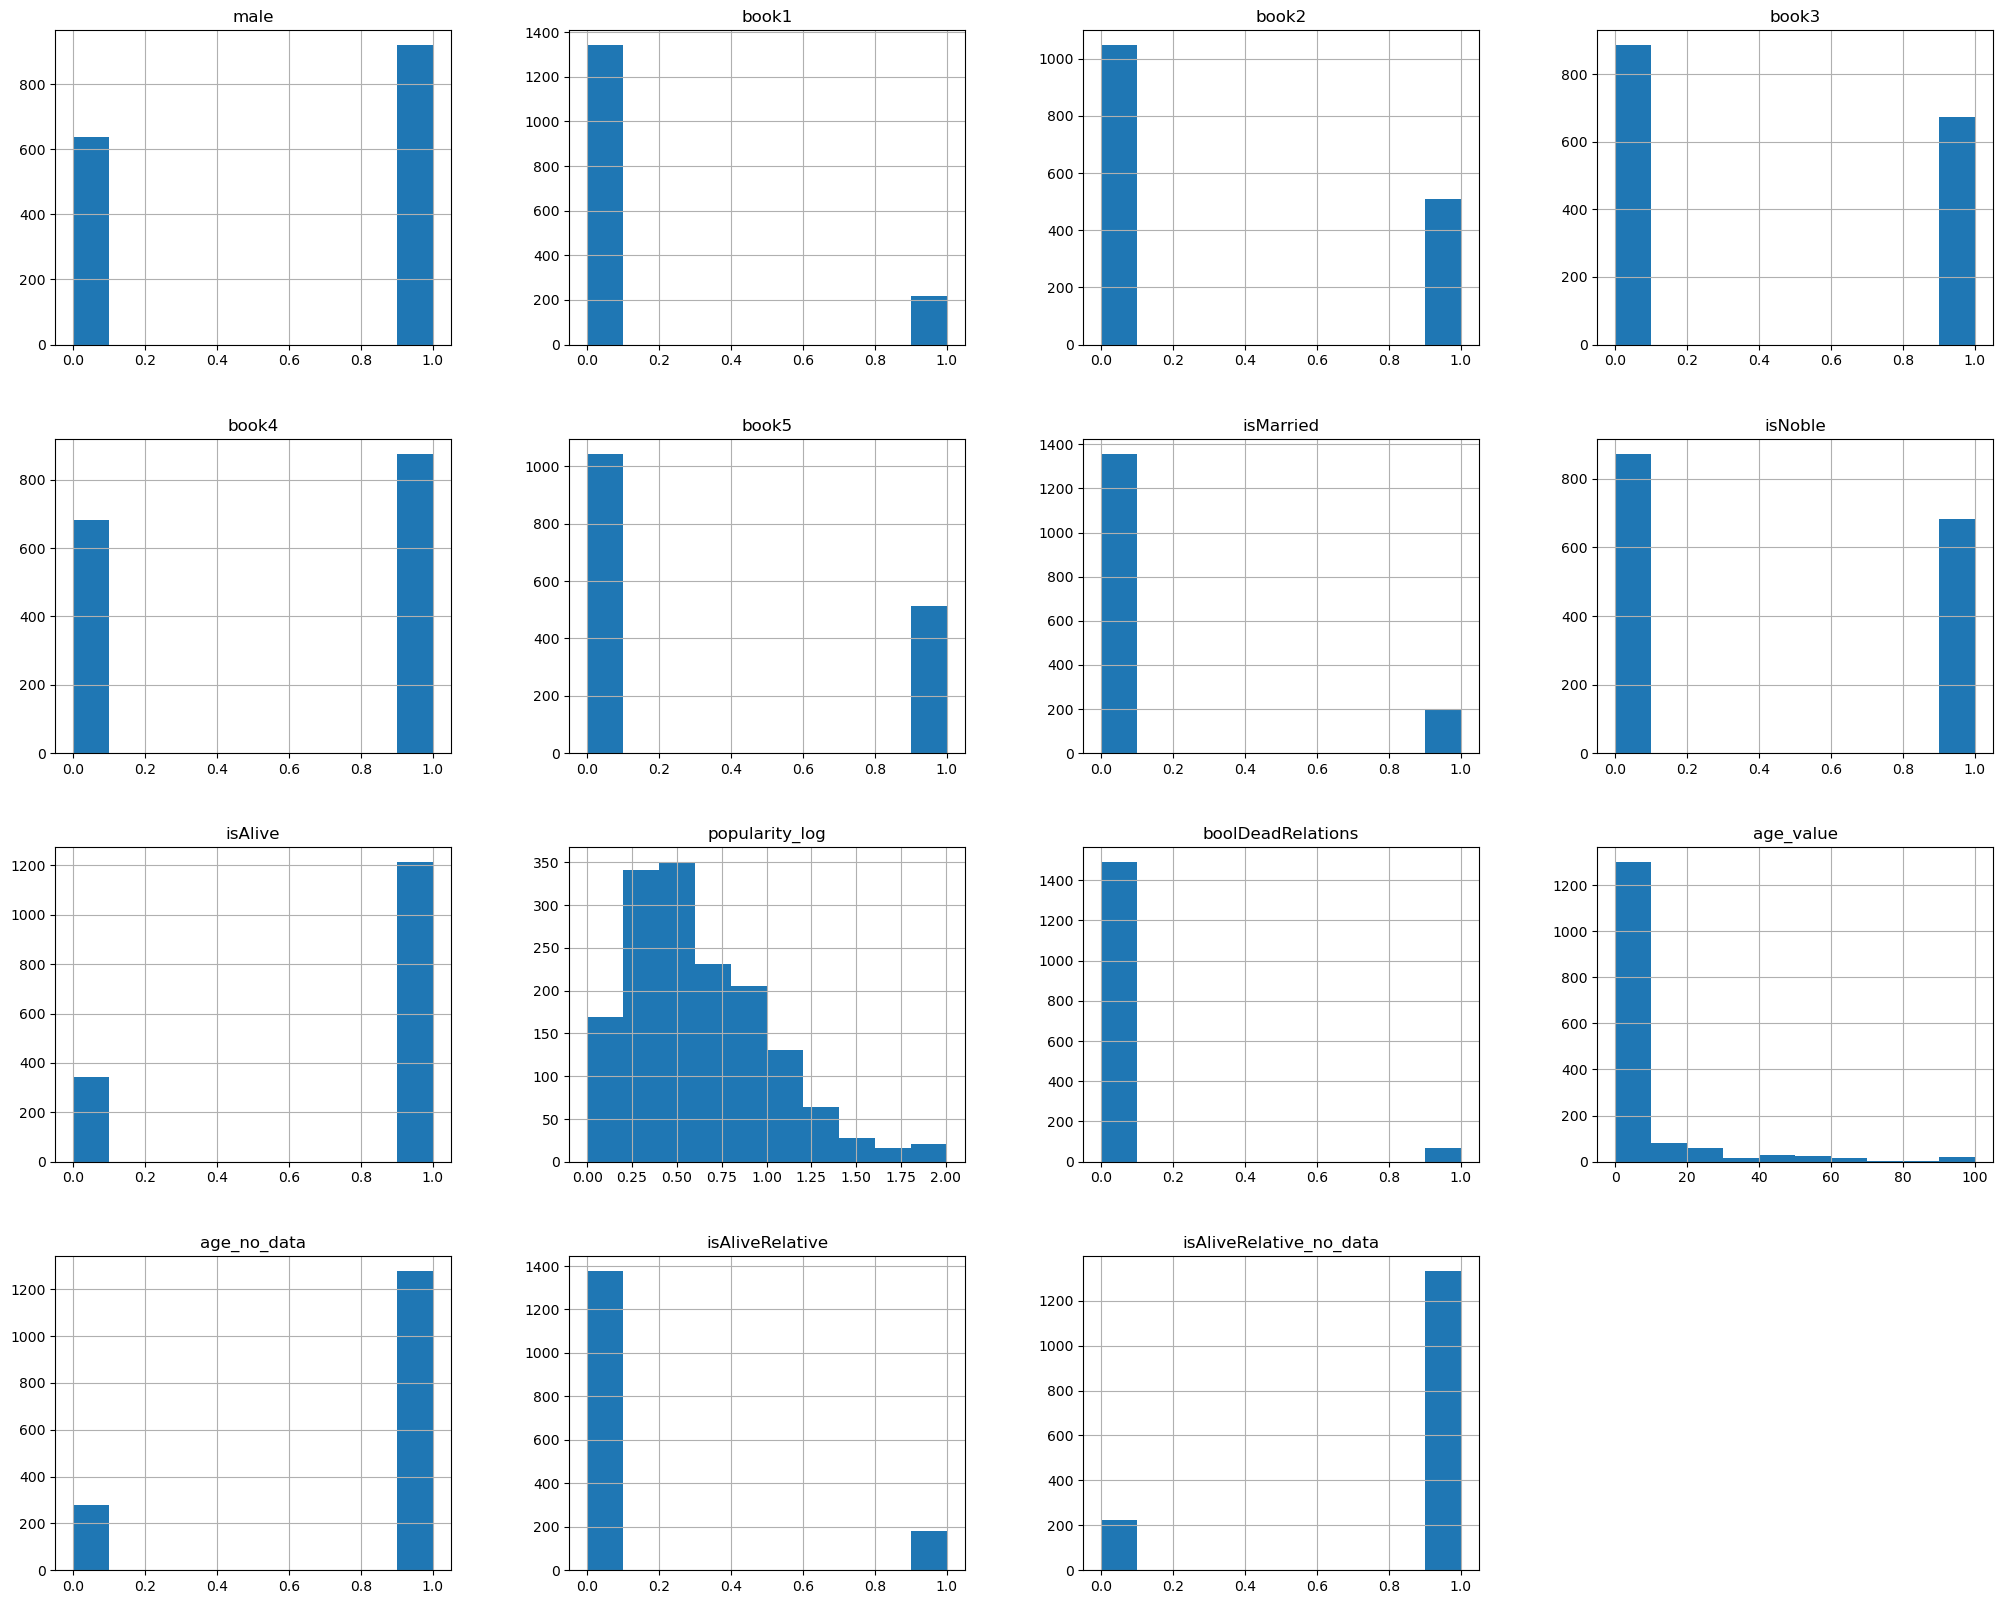

In [258]:
data.hist(figsize=(25, 20))

### Качественные признаки

In [259]:
# пока тут, потом избавимся от части и часть преобразуем
categorical_features = data.select_dtypes(include='object').columns.tolist()
categorical_features

['name', 'title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse']

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов. Давайте посмотрим, какие значения принимает данный признак.

In [260]:
data['culture'].value_counts(dropna=False)

NaN                        1069
Northmen                     94
Ironborn                     91
Free Folk                    45
Braavosi                     39
Valyrian                     28
Dornish                      17
Dothraki                     17
Ghiscari                     17
Reach                        13
Vale mountain clans          12
Valemen                      10
Rivermen                     10
northmen                      9
Westerman                     8
Free folk                     7
Tyroshi                       6
Qartheen                      5
Summer Isles                  4
Stormlands                    4
Astapori                      4
Ironmen                       3
Dornishmen                    3
Northern mountain clans       3
Westermen                     3
Westeros                      3
Myrish                        2
Crannogmen                    2
Meereenese                    2
First Men                     2
westermen                     2
Lysene  

Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [261]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

In [262]:
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted.update({v:k})

cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

In [263]:
# Теперь создадим новый столбец с укрупненными значениями culture. Вместо 51 значений получим 12, остановимся на этом
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')
data['culture_grouped'].isna().sum()

0

In [264]:
# Количество уникальнх значений в каждом столбце
data.nunique()

name                       1557
title                       195
male                          2
culture                      51
mother                       16
father                       19
heir                         20
house                       315
spouse                      186
book1                         2
book2                         2
book3                         2
book4                         2
book5                         2
isMarried                     2
isNoble                       2
isAlive                       2
popularity_log              117
boolDeadRelations             2
age_value                    72
age_no_data                   2
isAliveRelative               2
isAliveRelative_no_data       2
culture_grouped              12
dtype: int64

Похожим образом сгруппируем и преобразуем `house` (Дома). У нас 315 уникальных значений, принадлежность многих персонажей к домам неизвестна (NaN), или в Доме только один человек. Оставим только крупные (и предположительно более влиятельные), а все остальные объединим в `Rare House`, Nan - в `Unknown House`. Предположим, что если в Доме больше или равно 15 человек, он крупный. Таких домов 9.

In [265]:
data['house'].value_counts(dropna=False)

NaN                 381
House Frey           89
Night's Watch        88
House Stark          56
House Targaryen      40
                   ... 
House Celtigar        1
House of Ghazeen      1
House Byrch           1
House Hawick          1
House Moore           1
Name: house, Length: 316, dtype: int64

In [266]:
big_houses = data['house'].value_counts()[lambda x: x >= 15].index.tolist()
big_houses

['House Frey',
 "Night's Watch",
 'House Stark',
 'House Targaryen',
 'House Lannister',
 'House Tyrell',
 'House Greyjoy',
 'House Osgrey',
 'Faith of the Seven']

In [267]:
# создадим новый признак house_grouped. Если NaN - unknown_house, если не в Big Houses - rare_house
data['house_grouped'] = np.where(
    data['house'].isna(),
    'unknown_house',
    np.where(
        data['house'].isin(big_houses),
        data['house'],
        'rare_house'
    )
)

Обработаем категориальные признаки `culture_grouped` и `house_grouped` и переведем их в числа, с помощью one hot encoding.

In [268]:
grouped_columns = ['culture_grouped', 'house_grouped']
data_ohe = pd.get_dummies(data[grouped_columns], prefix=grouped_columns)
data = pd.concat([data, data_ohe], axis=1)

Остальные категориальные признаки мы не будем учитывать при построении модели, удалим их из нашего датасета. 

In [269]:
data.drop(categorical_features + ['culture_grouped', 'house_grouped'], axis=1, inplace=True)

### Анализ признаков

Все наши данные приведены в числовые, теперь можно провести анализ, посмотреть на корреляцию и т.д. Это мы и сделаем. Проанализируем влияние признаков на целевую переменную `isAlive`.

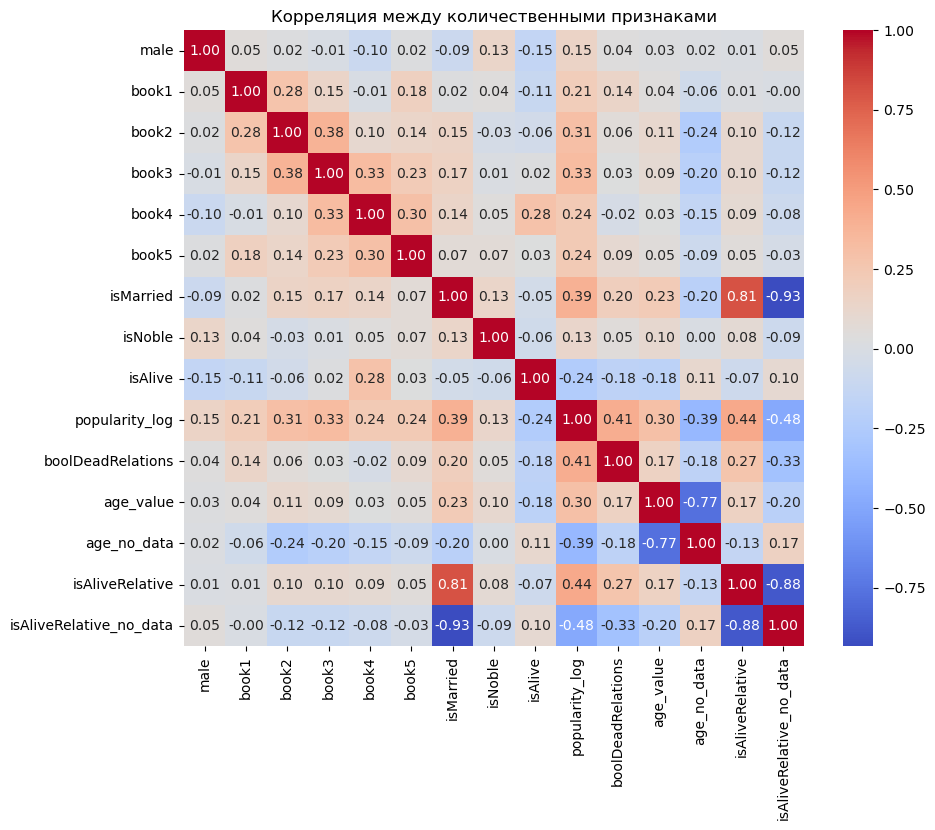

In [270]:
plt.figure(figsize=(10,8))
sns.heatmap(data[numeric_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция между количественными признаками')
plt.show()

In [271]:
all_columns= data.columns.to_list()
categorical_features_house = [
    col for col in all_columns 
    if (col not in numeric_features or col == 'isAlive') 
    and 'culture' not in col
]
categorical_features_culture = [
    col for col in all_columns 
    if (col not in numeric_features or col == 'isAlive') 
    and 'house' not in col
]

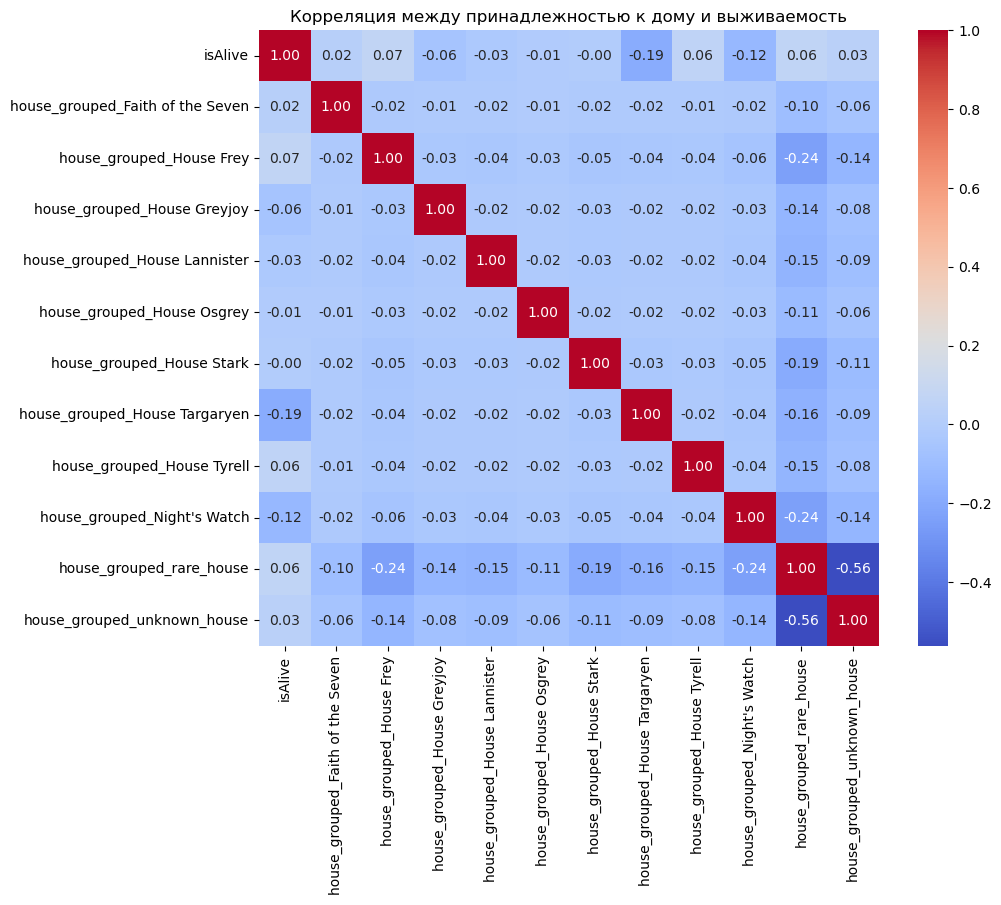

In [272]:
plt.figure(figsize=(10,8))
sns.heatmap(data[categorical_features_house].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция между принадлежностью к дому и выживаемость')
plt.show()

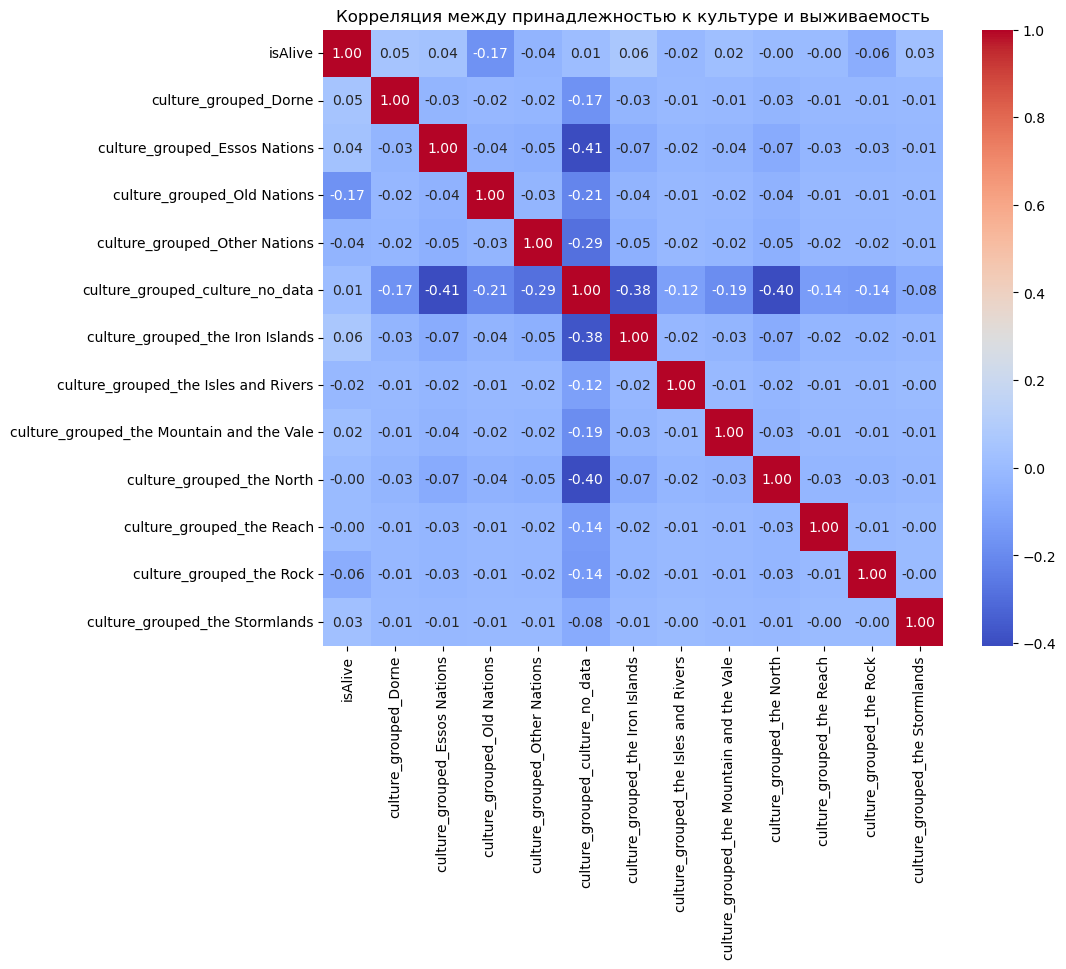

In [273]:
plt.figure(figsize=(10,8))
sns.heatmap(data[categorical_features_culture].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция между принадлежностью к культуре и выживаемость')
plt.show()

In [274]:
data.groupby('isAliveRelative')['isAlive'].mean()

isAliveRelative
0    0.789397
1    0.694444
Name: isAlive, dtype: float64

In [275]:
age_bins = pd.cut(data['age_value'], bins=[0, 20, 40, 60, 80, 100])
data.groupby(age_bins)['isAlive'].mean()

age_value
(0, 20]      0.772727
(20, 40]     0.718310
(40, 60]     0.698113
(60, 80]     0.705882
(80, 100]    0.153846
Name: isAlive, dtype: float64

Исходя из корреляции уже можно сделать какие-то выводы, например, если вы хотите выжить в Игре престолов, лучше быть женским персонажем книги 4 и относительно популярным, без связей с мертвыми людьми, и чтобы никто не знал вашего возраста и умер ли кто-нибудь в вашей семье. Хуже всего быть представителем Старых Наций, одним из Таргариенов или Ночного Дозора.

Создадим переменные `X`, которая будет хранить только значения признаков, которые мы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [277]:
X = data.drop(columns=['isAlive'])
y = data['isAlive']

In [278]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,        # 20% данных на валидацию
    random_state=7,       # фиксируем random_state для повторяемости
    stratify=y            # (опционально) чтобы сохранить пропорции классов
)

## Часть 2. Обучение моделей

Вым можете работать с одно из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier

Возьмем модели широко - регрессию, дерево, KNN и т.д.

In [310]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Создаем модели
models = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=7)),
    'RandomForest': RandomForestClassifier(random_state=7),
    'AdaBoost': AdaBoostClassifier(random_state=7),
    'GaussianNB': make_pipeline(StandardScaler(), GaussianNB()),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier())
}

best_accuracy = 0
best_model = None

# Обучаем модели на тренировочных данных
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    # Оцениваем качество 
    accuracy = accuracy_score(y_val, y_pred)
    print(f"*** {name} ***")
    print("Accuracy : %.4f" % accuracy)
    print(classification_report(y_val, y_pred))
    print("\n")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

*** LogisticRegression ***
Accuracy : 0.7981
              precision    recall  f1-score   support

           0       0.60      0.26      0.36        69
           1       0.82      0.95      0.88       243

    accuracy                           0.80       312
   macro avg       0.71      0.61      0.62       312
weighted avg       0.77      0.80      0.77       312



*** RandomForest ***
Accuracy : 0.8205
              precision    recall  f1-score   support

           0       0.64      0.43      0.52        69
           1       0.85      0.93      0.89       243

    accuracy                           0.82       312
   macro avg       0.75      0.68      0.70       312
weighted avg       0.81      0.82      0.81       312



*** AdaBoost ***
Accuracy : 0.7788
              precision    recall  f1-score   support

           0       0.50      0.29      0.37        69
           1       0.82      0.92      0.87       243

    accuracy                           0.78       312
   ma

## Часть 3. Оцените качество моделей

*** RandomForest ***
Accuracy : 0.8205 - будем работать с этой моделью, она показала лучший результат

### Тестовый датасет

In [294]:
data_test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [295]:
data_test.describe().T.assign(NaN_percent = ((data_test.isna().sum() / len(data_test)) * 100).round(2) )

,count,mean,std,min,25%,50%,75%,max,NaN_percent
male,389.0,0.732648,0.443148,0.0,0.000000,1.000000,1.000000,1.0,0.00
dateOfBirth,154.0,3986.571429,32738.182560,-28.0,239.000000,267.000000,280.000000,298299.0,60.41
book1,389.0,0.437018,0.496656,0.0,0.000000,0.000000,1.000000,1.0,0.00
book2,389.0,0.562982,0.496656,0.0,0.000000,1.000000,1.000000,1.0,0.00
book3,389.0,0.676093,0.468568,0.0,0.000000,1.000000,1.000000,1.0,0.00
book4,389.0,0.709512,0.454572,0.0,0.000000,1.000000,1.000000,1.0,0.00
book5,389.0,0.655527,0.475808,0.0,0.000000,1.000000,1.000000,1.0,0.00
isAliveMother,3.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0,99.23
isAliveFather,4.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,98.97
isAliveHeir,2.0,0.500000,0.707107,0.0,0.250000,0.500000,0.750000,1.0,99.49


In [298]:
data_test.loc[data_test['age']<0]


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,


Видим, что в признаках `dateOfBirth` и `age` какие-то странные данные, подумаем, как можно устранить ошибки. И хоть `dateOfBirth` мы в моделях не используем, но `age` нам понадобится

In [ ]:
#Вы можете аккуратно поправить тестовые данные:
data_test.loc[1685, 'dateOfBirth'] = 278
data_test.loc[1685, 'age'] = 20
data_test.loc[1869, 'dateOfBirth'] = 299
data_test.loc[1869, 'age'] = 0

#NB - мы здесь точечно поправили данные, потому что их можно загуглить, но по идее надо было бы сделать обработчик, чтобы
# автоматически преобразовывать данные, а не делать это вручную

Преобразуем признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные.

In [300]:
# Можно это сделать через кастомный препроцессор или через встроенные sklearn методы. Но мы сделали в лоб. 

# все используемые переменные для трейна мы уже определяли, так что переиспользуем их 
# M, cultures_grouped_inverted, big_houses, grouped_columns

# Числовые признаки
data_test['popularity_log'] = np.log10(data_test['popularity'] * M + 1)

data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

data_test['age_value'] = data_test['age'].apply(lambda x: x if x > 0 else 0)
data_test['age_no_data'] = [1 if np.isnan(x) else 0 for x in data_test['age']]

alive_df = data_test[alive_relatives_columns]
data_test['isAliveRelative'] = np.where(
    alive_df.eq(1).any(axis=1), 1,  # если есть хотя бы один 1 → 1
    0                               # иначе (все 0 и/или NaN) → 0
)
data_test['isAliveRelative_no_data'] = alive_df.isna().all(axis=1).astype(int)

# Почистим датасет
data_test.drop([
    'dateOfBirth', 'isAliveMother','isAliveFather', 'isAliveHeir','isAliveSpouse', 'age', 'numDeadRelations', 'popularity'
    ],axis=1, inplace=True
)

#Качественные признаки
data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

data_test['house_grouped'] = np.where(
    data_test['house'].isna(),
    'unknown_house',
    np.where(
        data_test['house'].isin(big_houses),
        data_test['house'],
        'rare_house'
    )
)

data_ohe_test = pd.get_dummies(data_test[grouped_columns], prefix=grouped_columns)
data_test = pd.concat([data_test, data_ohe_test], axis=1)

# Почистим датасет
data_test.drop(categorical_features + ['culture_grouped', 'house_grouped'], axis=1, inplace=True)

In [301]:
data_test.head()

,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity_log,boolDeadRelations,...,house_grouped_House Frey,house_grouped_House Greyjoy,house_grouped_House Lannister,house_grouped_House Osgrey,house_grouped_House Stark,house_grouped_House Targaryen,house_grouped_House Tyrell,house_grouped_Night's Watch,house_grouped_rare_house,house_grouped_unknown_house
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0.779360,0,...,0,0,0,0,0,0,0,0,1,0
1559,0,0,1,1,1,1,0,0,1.878418,0,...,0,0,0,0,0,0,0,0,1,0
1560,0,0,0,1,1,0,0,0,0.301756,0,...,0,0,0,0,0,0,0,0,1,0
1561,1,1,1,1,1,1,0,1,1.363115,0,...,0,0,0,0,0,0,0,0,1,0
1562,1,1,1,1,1,1,1,0,1.648148,0,...,1,0,0,0,0,0,0,0,0,0


Применим лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [308]:
features= X.columns.tolist()
X_test = data_test[features]

In [315]:
# Делаем предсказания на тесте
y_test_pred = best_model.predict(X_test)
y_test_pred

array([0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,

### Файл `submission.csv`

In [316]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /Users/scully/deep learning school/part 1/submission.csv
100%|██████████████████████████████████████| 2.74k/2.74k [00:00<00:00, 13.1MB/s]


In [322]:
submission = pd.read_csv("submission.csv", index_col='S.No')

In [323]:
submission['isAlive'] = y_test_pred

In [324]:
submission.to_csv("new_submission.csv", index=False)

In [ ]:
# upd - accuracy на тесте
# Accuracy вашего решения равен 0.6915167095115681.